Import các thư viện cần thiết

In [1]:
import numpy as np
import sys
import os
import matplotlib.pyplot as plt

# Thêm thư mục cha (L02) vào sys.path
parent_path = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if parent_path not in sys.path:
    sys.path.append(parent_path)

from src.data_processing import load_csv
from src.visualization import visua_hist, visua_boxplot, visua_scatter

Đọc dữ liệu và cho dữ liệu có số hàng số cột (Load data)

In [2]:
DATA_PATH = "../data/raw/BankChurners.csv"
data, header = load_csv(DATA_PATH)

print("Shape:", data.shape)
print("Header:", header)
print("First row:", data[0])

Shape: (10127, 23)
Header: ['"CLIENTNUM"', '"Attrition_Flag"', '"Customer_Age"', '"Gender"', '"Dependent_count"', '"Education_Level"', '"Marital_Status"', '"Income_Category"', '"Card_Category"', '"Months_on_book"', '"Total_Relationship_Count"', '"Months_Inactive_12_mon"', '"Contacts_Count_12_mon"', '"Credit_Limit"', '"Total_Revolving_Bal"', '"Avg_Open_To_Buy"', '"Total_Amt_Chng_Q4_Q1"', '"Total_Trans_Amt"', '"Total_Trans_Ct"', '"Total_Ct_Chng_Q4_Q1"', '"Avg_Utilization_Ratio"', '"Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1"', '"Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2"']
First row: ['768805383' '"Existing Customer"' '45' '"M"' '3' '"High School"'
 '"Married"' '"$60K - $80K"' '"Blue"' '39' '5' '1' '3' '12691' '777'
 '11914' '1.335' '1144' '42' '1.625' '0.061' '9.3448e-05' '0.99991']


Có giá trị bị thiếu (missing value) ở các cột không?

In [3]:
missing_mask = (data == '') | (data == 'NaN') | (data == 'nan') | (data == '?')
missing_counts = np.sum(missing_mask, axis=0)

print("Number of missing value in each column:")
for col_name, count in zip(header, missing_counts):
    print(f"{col_name}: {count}")


Number of missing value in each column:
"CLIENTNUM": 0
"Attrition_Flag": 0
"Customer_Age": 0
"Gender": 0
"Dependent_count": 0
"Education_Level": 0
"Marital_Status": 0
"Income_Category": 0
"Card_Category": 0
"Months_on_book": 0
"Total_Relationship_Count": 0
"Months_Inactive_12_mon": 0
"Contacts_Count_12_mon": 0
"Credit_Limit": 0
"Total_Revolving_Bal": 0
"Avg_Open_To_Buy": 0
"Total_Amt_Chng_Q4_Q1": 0
"Total_Trans_Amt": 0
"Total_Trans_Ct": 0
"Total_Ct_Chng_Q4_Q1": 0
"Avg_Utilization_Ratio": 0
"Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1": 0
"Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2": 0


➡️ **Nhận xét**: 
- Không có giá trị thiếu (missing value) tất cả cột đều đủ dữ liệu.

Xem số giá trị duy nhất của từng đặc trưng (Categorical Analysis)

In [4]:
for i in range(data.shape[1]):
    uni_i = np.unique(data[:, i])
    print(header[i], " - Count unique:", len(uni_i))
    print("- Example: ",uni_i[:2])

"CLIENTNUM"  - Count unique: 10127
- Example:  ['708082083' '708083283']
"Attrition_Flag"  - Count unique: 2
- Example:  ['"Attrited Customer"' '"Existing Customer"']
"Customer_Age"  - Count unique: 45
- Example:  ['26' '27']
"Gender"  - Count unique: 2
- Example:  ['"F"' '"M"']
"Dependent_count"  - Count unique: 6
- Example:  ['0' '1']
"Education_Level"  - Count unique: 7
- Example:  ['"College"' '"Doctorate"']
"Marital_Status"  - Count unique: 4
- Example:  ['"Divorced"' '"Married"']
"Income_Category"  - Count unique: 6
- Example:  ['"$120K +"' '"$40K - $60K"']
"Card_Category"  - Count unique: 4
- Example:  ['"Blue"' '"Gold"']
"Months_on_book"  - Count unique: 44
- Example:  ['13' '14']
"Total_Relationship_Count"  - Count unique: 6
- Example:  ['1' '2']
"Months_Inactive_12_mon"  - Count unique: 7
- Example:  ['0' '1']
"Contacts_Count_12_mon"  - Count unique: 7
- Example:  ['0' '1']
"Credit_Limit"  - Count unique: 6205
- Example:  ['10001' '10007']
"Total_Revolving_Bal"  - Count uniqu

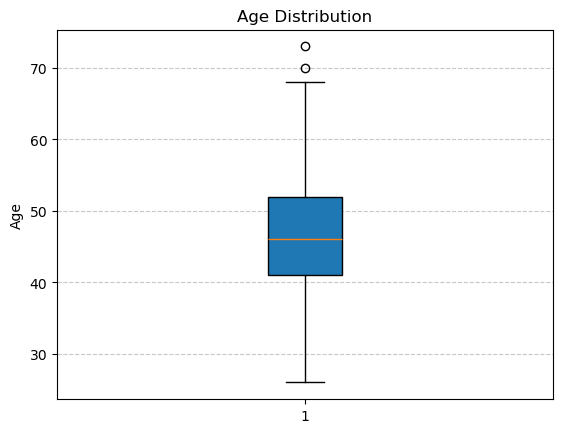

In [13]:
Customer_Age = data[:,2].astype(int)
visua_boxplot(Customer_Age, "Age Distribution", "", "Age")

➡️ **Nhận xét**: 
- Có 2 outliers, một điểm ở khoảng 70 tuổi.
- Tệp khách hàng có xu hướng tập trung mạnh ở độ tuổi trung niên. Với 50% khách hàng nằm gọn trong khoảng 41-52 tuổi.

Vẽ biểu đồ bar chart thể hiện giá trị dữ liệu và tần suất xuất hiện của chúng

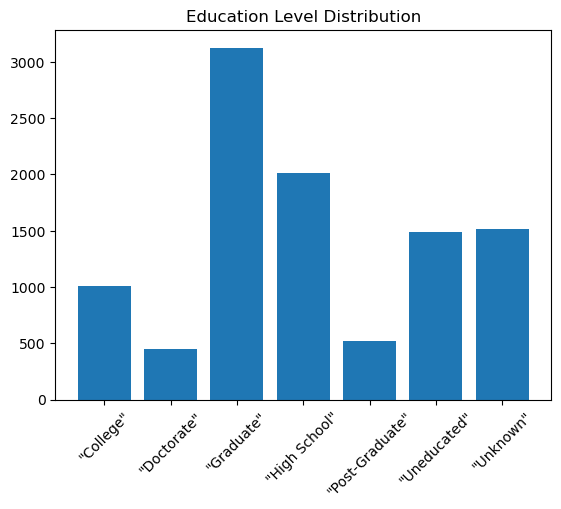

In [ ]:

# Education Level
edu_idx = header.index('"Education_Level"')
unique_edu, edu_counts = np.unique(data[:, edu_idx], return_counts=True)

plt.figure()
plt.bar(unique_edu, edu_counts)
plt.xticks(rotation=45)
plt.title("Education Level Distribution")
plt.show()

➡️ **Nhận xét**: 
- Trình độ học vấn "Graduate" (Tốt nghiệp đại học) chiếm tần số lớn nhất, cho biết đa số khách hàng là sinh viên.
- Phân bố dữ liệu không đều nhóm "Graduate" chiếm số lượng lớn nhất một cách rõ rệt, với khoảng 3100 khách hàng trong khi
Giá trị "Doctorate" chiếm tỉ trọng ít nhất trong nhóm chỉ với 500 khách hàng.
- Nhóm "High School" (Trung học Phổ thông) đứng ở vị trí thứ hai (khoảng 2000).
- Việc có một số lượng đáng kể (khoảng 1500) ở nhóm "Unknown" cho thấy dữ liệu cần được xử lí.


Vẽ biều đồ Scatter để phân tích mối liên hệ giữa các đặc trưng

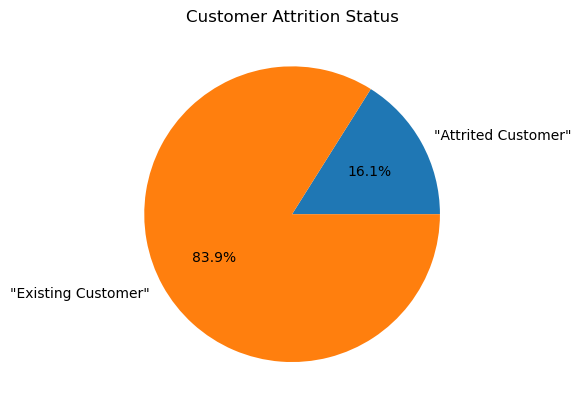

In [ ]:
# Phân tích đặc trưng Attrition_Flag
attr_idx = header.index('"Attrition_Flag"')
unique_attr, attr_counts = np.unique(data[:, attr_idx], return_counts=True)

plt.figure()
plt.pie(attr_counts, labels=unique_attr, autopct='%1.1f%%')
plt.title("Customer Attrition Status")
plt.show()

➡️ **Nhận xét**: 
- Số khách hàng rời bỏ sẽ có giá trị "Attrited Customer" và đang chiểm tỉ trọng khá lớn 16.1%.